In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

In [2]:

df = pd.read_csv("banking_loan_approval_dataset_100k.csv")

In [3]:
df.head()

,age,job,marital,education,default,balance,housing_loan,personal_loan,contact,day,month,duration,campaign,pdays,previous,poutcome,LOAN_APPROVAL
0,56,retired,married,tertiary,0,102856,1,0,cellular,21,sep,798,16,343,0,failure,1
1,69,student,single,tertiary,1,64751,0,0,cellular,20,may,250,15,466,3,success,0
2,46,services,divorced,tertiary,0,88210,1,1,telephone,3,mar,268,15,476,2,success,1
3,32,services,married,primary,0,39552,0,1,cellular,13,aug,671,4,487,8,unknown,1
4,60,student,divorced,secondary,0,14103,0,0,cellular,9,jul,1859,5,242,1,unknown,1


In [4]:
df.info

<bound method DataFrame.info of        age         job   marital  education  default  balance  housing_loan  \
0       56     retired   married   tertiary        0   102856             1   
1       69     student    single   tertiary        1    64751             0   
2       46    services  divorced   tertiary        0    88210             1   
3       32    services   married    primary        0    39552             0   
4       60     student  divorced  secondary        0    14103             0   
...    ...         ...       ...        ...      ...      ...           ...   
99995   67     student    single    primary        0   123524             0   
99996   58    services   married    primary        0    64071             0   
99997   45       admin  divorced   tertiary        0    75862             1   
99998   18  technician    single   tertiary        1     1883             1   
99999   19       admin  divorced  secondary        0    13347             1   

       personal_loa

In [5]:
df.shape

(100000, 17)

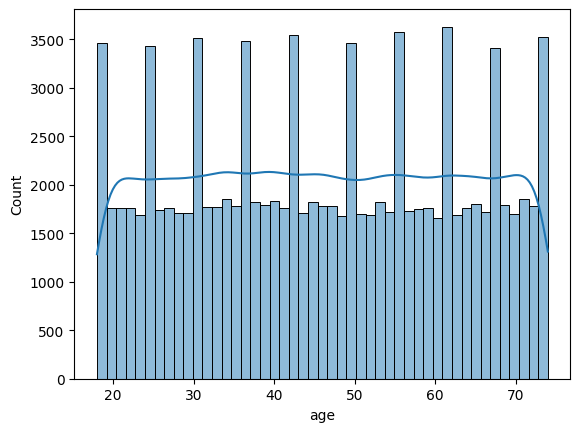

In [7]:
sns.histplot(df['age'] , kde=True)
plt.show()

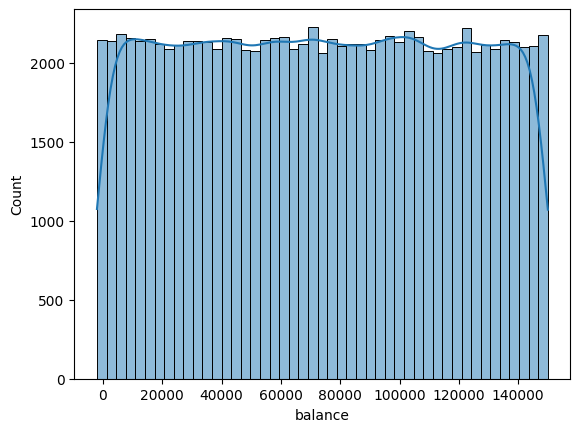

In [8]:
sns.histplot(df['balance'], kde=True)
plt.show()


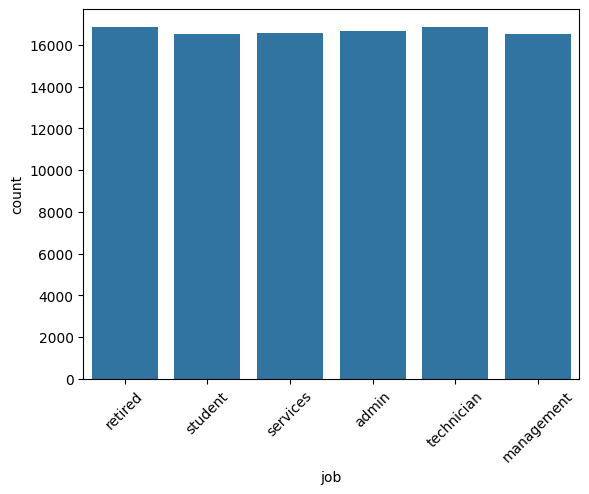

In [9]:
sns.countplot(x='job', data=df)
plt.xticks(rotation=45)
plt.show()

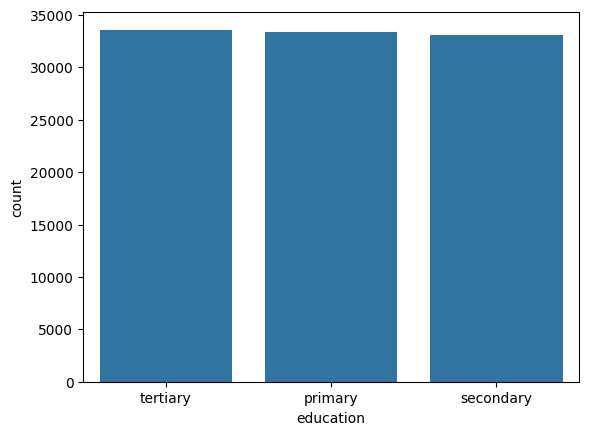

In [10]:
sns.countplot(x='education', data=df)
plt.show()

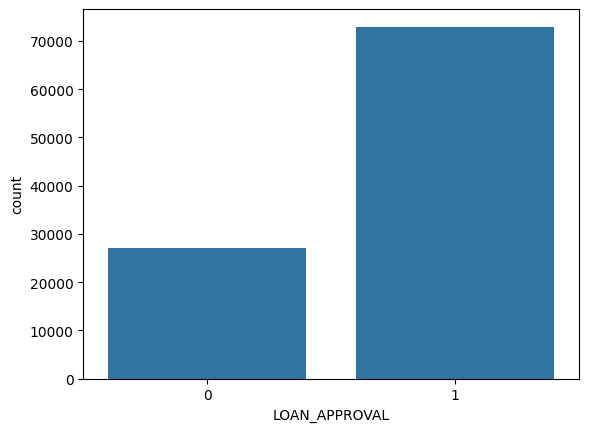

In [11]:
sns.countplot(x='LOAN_APPROVAL', data=df)
plt.show()

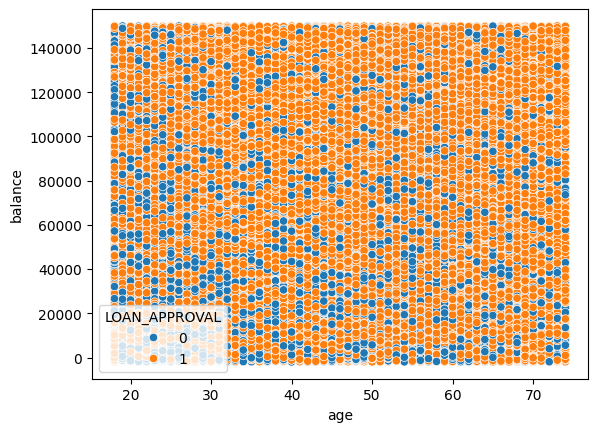

In [12]:
sns.scatterplot(x='age', y='balance', hue='LOAN_APPROVAL', data=df)
plt.show()

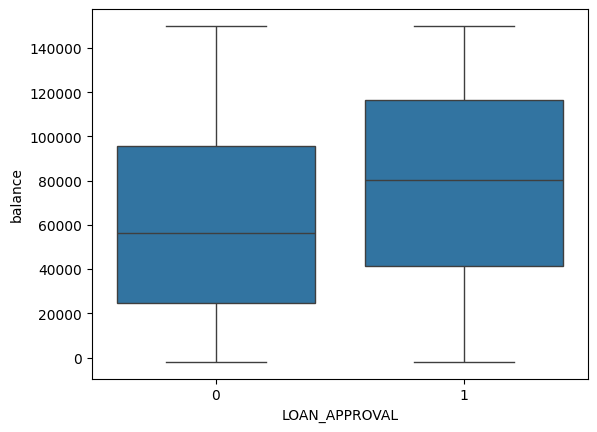

In [13]:
sns.boxplot(x='LOAN_APPROVAL', y='balance', data=df)
plt.show()

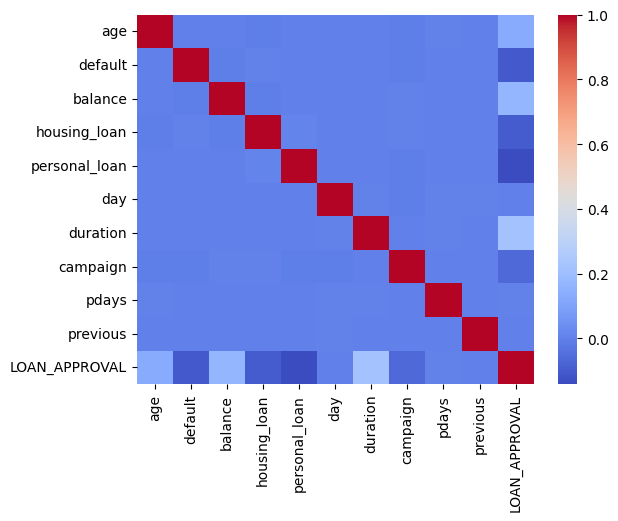

In [14]:
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.show()

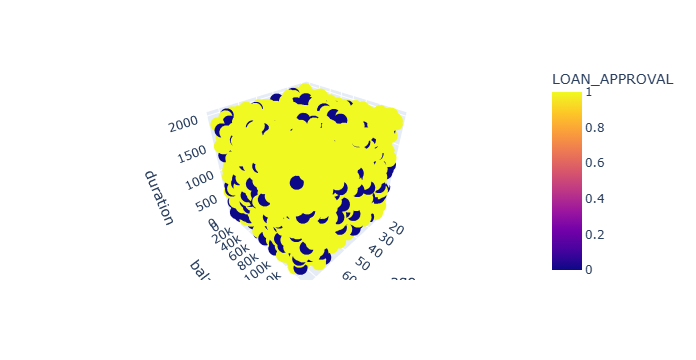

In [17]:
fig = px.scatter_3d(df.sample(5000), x='age', y='balance', z='duration', color='LOAN_APPROVAL')
fig.show()

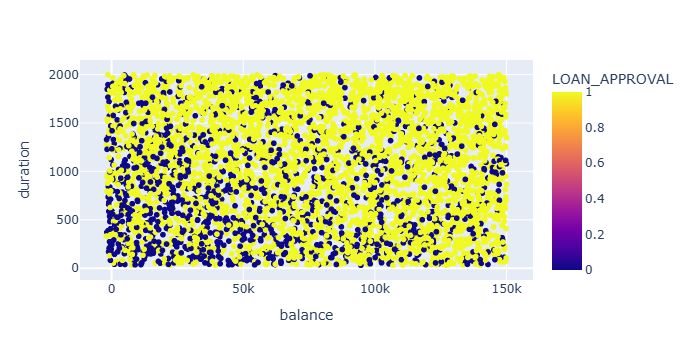

In [18]:
fig = px.scatter(df.sample(5000), x='balance', y='duration', color='LOAN_APPROVAL')
fig.show()

In [19]:
categorical_cols = df.select_dtypes(include='object').columns


In [20]:
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [21]:
X = df.drop('LOAN_APPROVAL', axis=1)
y = df['LOAN_APPROVAL']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [23]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}


In [24]:
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')


In [28]:
grid = GridSearchCV(model, param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train, y_train)

C:\Users\Parth\PycharmProjects\PythonProject3\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning:

[22:46:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.




,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1], 'learning_rate': [0.05, 0.1], 'max_depth': [4, 6, ...], 'n_estimators': [100, 200], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parame

In [29]:
best_model = grid.best_estimator_

In [30]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

In [31]:
print("Best Params:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Accuracy: 0.7524
ROC AUC: 0.7348829680143808
              precision    recall  f1-score   support

           0       0.60      0.25      0.35      5385
           1       0.77      0.94      0.85     14615

    accuracy                           0.75     20000
   macro avg       0.68      0.59      0.60     20000
weighted avg       0.72      0.75      0.71     20000

